
BASE VERSION: brighton_spaces_3.0.0

Comparing brighton_spaces_3.0.0_reprocess vs brighton_spaces_3.0.0
Common datasets: 1
SSIM: 0.4168 | ORB: 0.4017

Comparing brighton_spaces_3.0.0_reprocess1 vs brighton_spaces_3.0.0
Common datasets: 1
SSIM: 0.2653 | ORB: 0.3363

Comparing brighton_spaces_3.0.0_reprocess2 vs brighton_spaces_3.0.0
Common datasets: 1
SSIM: 0.4255 | ORB: 0.4472

Comparing brighton_spaces_3.0.0_reprocess3 vs brighton_spaces_3.0.0
Common datasets: 1
SSIM: 0.6564 | ORB: 0.2170

BASE VERSION: brighton_spaces_3.1.0

Comparing brighton_spaces_3.1.0_reprocess vs brighton_spaces_3.1.0
Common datasets: 1
SSIM: 0.9048 | ORB: 0.3902

Comparing brighton_spaces_3.1.0_reprocess1 vs brighton_spaces_3.1.0
Common datasets: 1
SSIM: 0.4552 | ORB: 0.4919

Comparing brighton_spaces_3.1.0_reprocess2 vs brighton_spaces_3.1.0
Common datasets: 1
SSIM: 0.4777 | ORB: 0.4426

Comparing brighton_spaces_3.1.0_reprocess3 vs brighton_spaces_3.1.0
Common datasets: 1
SSIM: 0.5061 | ORB: 0.3023

BASE VE

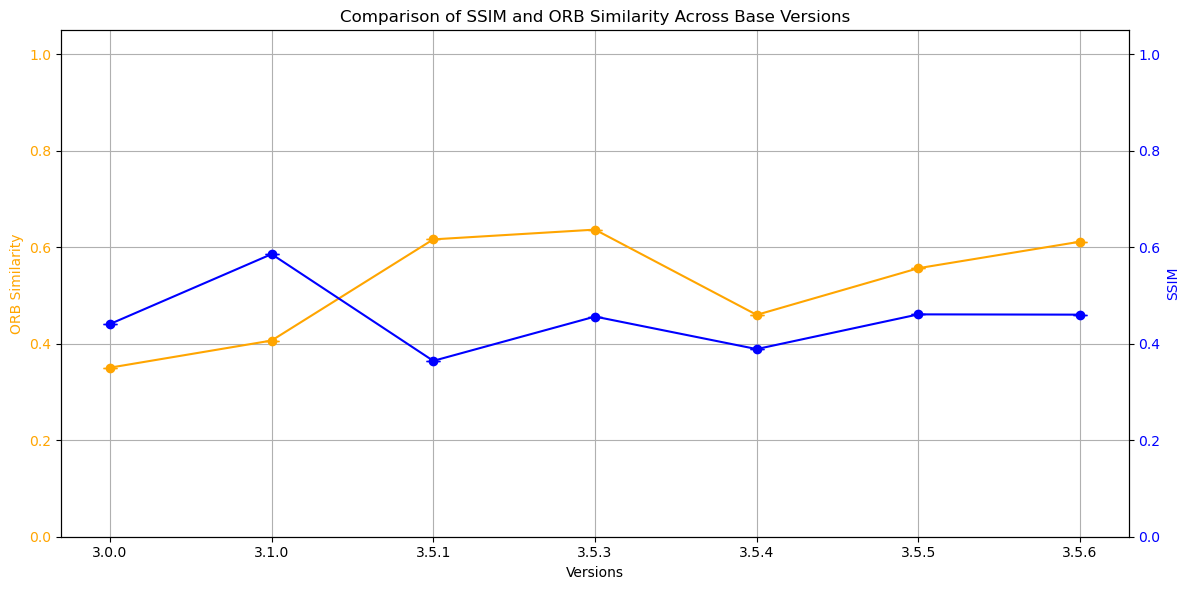

In [21]:
"""
Comparing images using ORB feature detector and structural similarity index,
with reprojection to match shapes/projections.
"""

import os
from pathlib import Path

import cv2
import numpy as np
from PIL import Image, ImageChops
from skimage.metrics import structural_similarity

import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import matplotlib.pyplot as plt

# --- Config: adjust these paths ---
reference_basepath = '/home/hubert/Documents/inversion_test/latest/datasets'
testbranch_basepath = '/home/hubert/Documents/inversion_test/latest/datasets'


# Temporary output for reprojection
out_reproj = '/tmp/out_reproj.tif'


def reproj_match(infile, matchfile, outfile, resampling="auto"):
    """
    Reproject infile into the exact geometry of matchfile (crs, transform, width, height).
    Preserves source dtype and band count.
    resampling: "auto", "bilinear", "cubic", or "nearest"
    """
    with rasterio.open(infile) as src, rasterio.open(matchfile) as m:
        dst_crs = m.crs
        dst_transform = m.transform
        dst_width = m.width
        dst_height = m.height

        dst_meta = src.meta.copy()
        dst_meta.update({
            "crs": dst_crs,
            "transform": dst_transform,
            "width": dst_width,
            "height": dst_height,
            "count": src.count,
            "dtype": src.dtypes[0],
            "nodata": src.nodata
        })

        if resampling == "auto":
            # use cubic for high-quality RGB/continuous imagery, otherwise bilinear
            if src.count >= 3 or src.dtypes[0].startswith("float"):
                resampling_method = Resampling.cubic
            else:
                resampling_method = Resampling.bilinear
        elif resampling == "cubic":
            resampling_method = Resampling.cubic
        elif resampling == "bilinear":
            resampling_method = Resampling.bilinear
        elif resampling == "nearest":
            resampling_method = Resampling.nearest
        else:
            raise ValueError("resampling must be one of: auto, cubic, bilinear, nearest")

        with rasterio.open(outfile, "w", **dst_meta) as dst:
            for b in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, b),
                    destination=rasterio.band(dst, b),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=dst_transform,
                    dst_crs=dst_crs,
                    resampling=resampling_method
                )

# Example usage:
# reproj_match("test/odm_orthophoto.tif", "ref/odm_orthophoto.tif", "/tmp/out_reproj.tif", resampling="auto")



def get_8bit_tif(path):
    """Read a TIFF with rasterio and return a single-channel 8-bit numpy array (grayscale).
    Respects nodata (if present) and normalizes to 0-255 using actual data range.
    """
    with rasterio.open(path) as src:
        arr = src.read()  # shape: (bands, H, W)
        nodata = src.nodata



    # Convert to (H, W, C) if multi-band
    if arr.ndim == 3:
        arr = np.transpose(arr, (1, 2, 0))  # H, W, C
    else:
        arr = arr  # unexpected but handle

    # If single band, ensure shape (H, W)
    if arr.ndim == 3 and arr.shape[2] == 1:
        gray = arr[:, :, 0].astype(np.float32)
    elif arr.ndim == 2:
        gray = arr.astype(np.float32)
    elif arr.ndim == 3 and arr.shape[2] >= 3:
        # assume first 3 bands are RGB (or RGB-ish); compute luminance
        rgb = arr[:, :, :3].astype(np.float32)
        weights = np.array([0.2989, 0.5870, 0.1140], dtype=np.float32)
        gray = np.tensordot(rgb, weights, axes=([2], [0]))
    else:
        # fallback mean across channel axis
        gray = np.mean(arr, axis=2).astype(np.float32)

    # Create valid-data mask using nodata or zeros
    if nodata is not None:
        valid_mask = np.any(arr != nodata, axis=-1) if arr.ndim == 3 else (arr != nodata)
    else:
        # treat all-zero pixels as invalid
        valid_mask = np.any(arr != 0, axis=-1) if arr.ndim == 3 else (arr != 0)

    # Use only valid pixels to compute min/max
    valid_vals = gray[valid_mask]
    if valid_vals.size == 0:
        # nothing valid: return zeros
        out = np.zeros_like(gray, dtype=np.uint8)
        return out

    minv = float(np.nanmin(valid_vals))
    maxv = float(np.nanmax(valid_vals))

    if maxv > minv:
        norm = (gray - minv) / (maxv - minv)
    else:
        norm = np.zeros_like(gray, dtype=np.float32)

    out = (np.clip(norm, 0.0, 1.0) * 255.0).round().astype(np.uint8)

    # Set nodata pixels to 0 for consistency
    out[~valid_mask] = 0
    return out, valid_mask          #i wasnt returning the valid mask


def interpret_results(ssim, orb):
    if ssim >= 0.95 and orb >= 0.80:
        return "PASS: Orthomosaics are highly consistent."
    elif ssim >= 0.80 and orb >= 0.60:
        return "WARNING: Minor differences detected."
    else:
        return "FAIL: Significant differences between orthomosaics."


def orb_sim(img1, img2):
    """ORB-based similarity: fraction of matches with distance < 50 (safe against no-descriptors)."""
    try:
        orb = cv2.ORB_create()
        kp_a, desc_a = orb.detectAndCompute(img1, None)
        kp_b, desc_b = orb.detectAndCompute(img2, None)
        if desc_a is None or desc_b is None:
            return 0.0
        bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
        matches = bf.match(desc_a, desc_b)
        if not matches:
            return 0.0
        similar_regions = [m for m in matches if m.distance < 50]
        return float(len(similar_regions)) / len(matches)
    except Exception as e:
        print("ORB error:", e)
        return 0.0


def structural_sim(img1, img2):
    """Compute SSIM; expects same shape. Return float in [-1,1] (1 identical)."""
    if img1.shape != img2.shape:
        raise ValueError("structural_sim: inputs must have same shape")
    a = img1.astype(np.float32) / 255.0
    b = img2.astype(np.float32) / 255.0
    sim = structural_similarity(a, b, data_range=1.0)
    return float(sim)



# Versions to compare
versions = []

base_versions = [
    "3.0.0", "3.1.0", "3.5.1", "3.5.3",
    "3.5.4", "3.5.5", "3.5.6"
]

for v in base_versions:
    prefix = f"brighton_spaces_{v}"
    versions.append(prefix)
    versions.append(f"{prefix}_reprocess")
    versions.append(f"{prefix}_reprocess1")
    versions.append(f"{prefix}_reprocess2")
    versions.append(f"{prefix}_reprocess3")


# Results for plotting (grouped by base version)
grouped = {}
for v in base_versions:

    referencebranch = f"brighton_spaces_{v}"

    print("\n====================================")
    print(f"BASE VERSION: {referencebranch}")
    print("====================================")

    # Build reference dictionary for THIS version
    tif_files_reference = list(Path(reference_basepath).glob(f'{referencebranch}/**/odm_orthophoto.tif'))
    reference_dict = {
        os.path.relpath(p, os.path.join(reference_basepath, referencebranch)): str(p)
        for p in tif_files_reference
    }

    # Only compare to its own reprocess runs
    test_versions = [
        f"{referencebranch}_reprocess",
        f"{referencebranch}_reprocess1",
        f"{referencebranch}_reprocess2",
        f"{referencebranch}_reprocess3"
    ]

    per_version_ssim = []
    per_version_orb = []

    for testbranch in test_versions:

        print(f"\nComparing {testbranch} vs {referencebranch}")

        tif_files_testbranch = list(Path(testbranch_basepath).glob(f'{testbranch}/**/odm_orthophoto.tif'))
        testbranch_dict = {
            os.path.relpath(p, os.path.join(testbranch_basepath, testbranch)): str(p)
            for p in tif_files_testbranch
        }

        common_keys = sorted(set(reference_dict.keys()) & set(testbranch_dict.keys()))
        print("Common datasets:", len(common_keys))

        for key in common_keys:
            ref_path = reference_dict[key]
            test_path = testbranch_dict[key]

            try:
                reproj_match(test_path, ref_path, out_reproj)

                img_ref, mask_ref = get_8bit_tif(ref_path)
                img_test_reproj, mask_test = get_8bit_tif(out_reproj)

                if img_ref.shape != img_test_reproj.shape:
                    img_test_reproj = cv2.resize(
                        img_test_reproj,
                        (img_ref.shape[1], img_ref.shape[0]),
                        interpolation=cv2.INTER_NEAREST
                    )

                mask_test = cv2.resize(
                    mask_test.astype(np.uint8),
                    (img_ref.shape[1], img_ref.shape[0]),
                    interpolation=cv2.INTER_NEAREST
                ) > 0

                common_mask = mask_ref & mask_test

                img_ref_masked = np.where(common_mask, img_ref, 0)
                img_test_masked = np.where(common_mask, img_test_reproj, 0)

                orb_similarity = orb_sim(img_ref_masked, img_test_masked)

                ssim_val = structural_similarity(
                    img_ref_masked.astype(np.float32) / 255.0,
                    img_test_masked.astype(np.float32) / 255.0,
                    data_range=1.0
                )

                print(f"SSIM: {ssim_val:.4f} | ORB: {orb_similarity:.4f}")

                per_version_ssim.append(ssim_val)
                per_version_orb.append(orb_similarity)

            except Exception as e:
                print("Error:", e)

    # Compute mean per base version
    if per_version_ssim:
        mean_ssim = float(np.mean(per_version_ssim))
        mean_orb = float(np.mean(per_version_orb))
    else:
        mean_ssim = 0.0
        mean_orb = 0.0

    # Store results
    base = v

    if base not in grouped:
        grouped[base] = {"ssim": [], "orb": []}

    grouped[base]["ssim"].append(mean_ssim)
    grouped[base]["orb"].append(mean_orb)
# Build clean arrays (one point per version)
# --- Prepare data for plotting with error bars and interpretation ---
x_labels = []
ssim_means = []
orb_means = []
ssim_std = []
orb_std = []
interpretations = []

for base in sorted(grouped.keys()):
    vals = grouped[base]
    mean_ssim = float(np.mean(vals["ssim"]))
    mean_orb = float(np.mean(vals["orb"]))
    std_ssim = float(np.std(vals["ssim"]))
    std_orb = float(np.std(vals["orb"]))
    
    x_labels.append(base)
    ssim_means.append(mean_ssim)
    orb_means.append(mean_orb)
    ssim_std.append(std_ssim)
    orb_std.append(std_orb)
    
    # Interpretation based on mean values
    interpretations.append(interpret_results(mean_ssim, mean_orb))

# Print summary table
print("\nSummary per base version:")
print(f"{'Version':<12} {'SSIM':>6} {'ORB':>6} {'Interpretation':<40}")
print("-"*70)
for i, v in enumerate(x_labels):
    print(f"{v:<12} {ssim_means[i]:6.3f} {orb_means[i]:6.3f} {interpretations[i]:<40}")

# --- Plot with error bars ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# ORB plot (left y-axis)
ax1.set_xlabel('Versions')
ax1.set_ylabel('ORB Similarity', color='orange')
ax1.errorbar(x_labels, orb_means, yerr=orb_std, fmt='o-', color='orange', capsize=5, label='ORB')
ax1.tick_params(axis='y', labelcolor='orange')
ax1.set_ylim(0, 1.05)

# SSIM plot (right y-axis)
ax2 = ax1.twinx()
ax2.set_ylabel('SSIM', color='blue')
ax2.errorbar(x_labels, ssim_means, yerr=ssim_std, fmt='o-', color='blue', capsize=5, label='SSIM')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.set_ylim(0, 1.05)

# Formatting
plt.title('Comparison of SSIM and ORB Similarity Across Base Versions')
ax1.grid(True)
plt.xticks(rotation=45, ha='right', fontsize=10)
fig.tight_layout()
plt.show()